# FraudGuard — Exploratory Data Analysis of PaySim

PaySim simulates mobile-money transactions over 30 days (744 hourly steps). Fraud is rare
(~0.13%) and only appears in `TRANSFER` and `CASH_OUT` transactions. This notebook looks at
the raw data, the class imbalance, the balance-reconciliation signal that makes fraud
detectable, and the time-aware split used for modelling.

> Run `python -m fraudguard.data` first so the processed splits exist.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from fraudguard.config import RAW_DATA_FILE, TARGET
from fraudguard.data import load_raw
from fraudguard.features import engineer_features

C = {"legit": "#2a78d6", "fraud": "#e34948", "grid": "#e6e5e1", "ink": "#52514e"}
df = load_raw(RAW_DATA_FILE)
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Schema, missing values, duplicates

In [2]:
print(df.dtypes.to_string())
print("\nmissing values per column:\n", df.isna().sum().to_string())
print("\nduplicate rows:", int(df.duplicated().sum()))
print("steps:", df.step.min(), "->", df.step.max())

step                 int32
type              category
amount             float64
nameOrig            string
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest            string
oldbalanceDest     float64
newbalanceDest     float64
isFraud               int8
isFlaggedFraud        int8

missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0

duplicate rows: 0
steps: 1 -> 743


## Class imbalance and fraud by transaction type

In [3]:
print("fraud rate: {:.4%}  ({:,} of {:,})".format(df[TARGET].mean(), int(df[TARGET].sum()), len(df)))
by_type = df.groupby("type", observed=True)[TARGET].agg(["count", "sum", "mean"]).rename(columns={"count": "rows", "sum": "fraud", "mean": "fraud_rate"})
by_type["fraud_rate"] = (by_type["fraud_rate"] * 100).round(3)
print(by_type.to_string())
print("\nisFlaggedFraud (business rule) flags only", int(df.isFlaggedFraud.sum()), "rows")

fraud rate: 0.1291%  (8,213 of 6,362,620)
             rows  fraud  fraud_rate
type                                
CASH_IN   1399284      0       0.000
CASH_OUT  2237500   4116       0.184
DEBIT       41432      0       0.000
PAYMENT   2151495      0       0.000
TRANSFER   532909   4097       0.769

isFlaggedFraud (business rule) flags only 16 rows


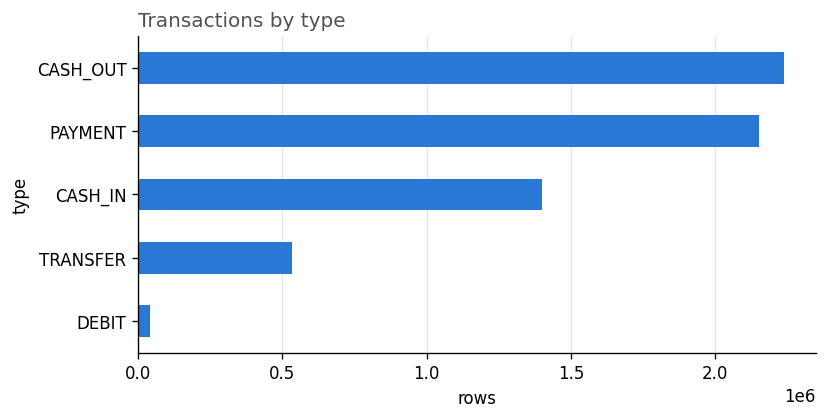

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6), dpi=120)
by_type["rows"].sort_values().plot.barh(ax=ax, color=C["legit"])
ax.set_title("Transactions by type", loc="left", color=C["ink"]); ax.set_xlabel("rows")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(axis="x", color=C["grid"]); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## Amount distributions: fraud vs legitimate

             count       mean        std  min       25%       50%        75%         max
isFraud                                                                                 
0        6354407.0   178197.0   596237.0  0.0   13368.0   74685.0   208365.0  92445517.0
1           8213.0  1467967.0  2404253.0  0.0  127091.0  441423.0  1517771.0  10000000.0


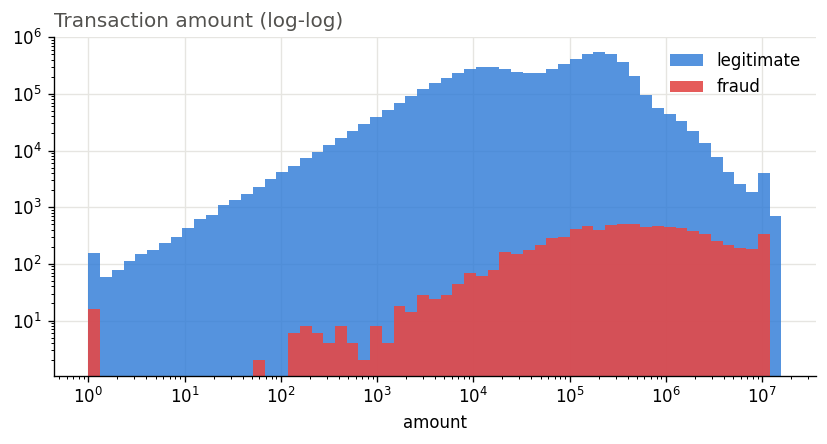

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.8), dpi=120)
bins = np.logspace(0, 7.2, 60)
ax.hist(df.loc[df[TARGET] == 0, "amount"].clip(lower=1), bins=bins, color=C["legit"], alpha=0.8, label="legitimate")
ax.hist(df.loc[df[TARGET] == 1, "amount"].clip(lower=1), bins=bins, color=C["fraud"], alpha=0.9, label="fraud")
ax.set_xscale("log"); ax.set_yscale("log"); ax.legend(frameon=False)
ax.set_title("Transaction amount (log-log)", loc="left", color=C["ink"]); ax.set_xlabel("amount")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(color=C["grid"]); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print(df.groupby(TARGET)["amount"].describe().round(0).to_string())

## The balance-reconciliation signal

For a clean transaction `newbalanceOrig + amount == oldbalanceOrg` and `oldbalanceDest + amount == newbalanceDest`. Fraudulent PaySim transactions drain the origin account and the destination balance is frequently not updated, so the *destination error* is large.

In [6]:
feat = engineer_features(df.sample(1_000_000, random_state=42))
cols = ["orig_emptied", "amount_equals_orig_balance", "dest_zero_before", "dest_zero_after", "orig_zero_before"]
summary = feat.groupby(TARGET)[cols].mean().T.rename(columns={0: "legit_rate", 1: "fraud_rate"}).round(3)
print(summary.to_string())
print("\nabs destination error (median):")
print(feat.groupby(TARGET)["error_balance_dest"].apply(lambda s: s.abs().median()).round(2).to_string())

isFraud                     legit_rate  fraud_rate
orig_emptied                     0.238       0.979
amount_equals_orig_balance       0.000       0.980
dest_zero_before                 0.425       0.664
dest_zero_after                  0.383       0.500
orig_zero_before                 0.331       0.001

abs destination error (median):
isFraud
0    5134.56
1    6146.14


## Fraud over time and the time-aware split

Legitimate traffic thins out after roughly step 400 while fraud continues at a steady rate, so the *last* 20% of steps (the test period) has a much higher fraud rate. This is genuine distribution shift between training and test and is one reason a chronological split is more honest than a random one.

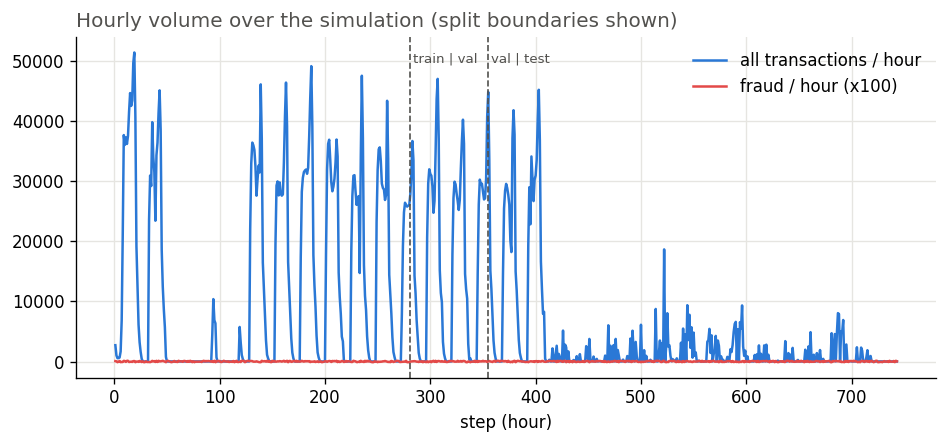

In [7]:
per_step = df.groupby("step")[TARGET].agg(["count", "sum"])
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=120)
ax.plot(per_step.index, per_step["count"], color=C["legit"], lw=1.5, label="all transactions / hour")
ax.plot(per_step.index, per_step["sum"] * 100, color=C["fraud"], lw=1.5, label="fraud / hour (x100)")
for x, lbl in [(281, "train | val"), (355, "val | test")]:
    ax.axvline(x, color=C["ink"], ls="--", lw=1); ax.text(x + 3, ax.get_ylim()[1] * 0.92, lbl, color=C["ink"], fontsize=8)
ax.set_title("Hourly volume over the simulation (split boundaries shown)", loc="left", color=C["ink"])
ax.set_xlabel("step (hour)"); ax.legend(frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(color=C["grid"]); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [8]:
import json
from fraudguard.data import SUMMARY_FILE
summary = json.loads(SUMMARY_FILE.read_text())
pd.DataFrame(summary["splits"]).set_index("split")

,rows,fraud,fraud_rate_pct,step_min,step_max
split,,,,,
train,3820599,3193,0.0836,1,281
validation,1293285,770,0.0595,282,355
test,1248736,4250,0.3403,356,743


## Takeaways

* Clean dataset: no missing values, no duplicates, five transaction types.
* Extreme imbalance (0.13% fraud) → PR-AUC, precision, recall and F1 are the right metrics; accuracy is meaningless.
* Fraud only occurs in `TRANSFER` and `CASH_OUT`; fraudsters typically empty the origin account and the destination balance is not updated — captured by `orig_emptied`, `amount_equals_orig_balance` and `error_balance_dest`.
* The chronological split exposes real drift: the test period's fraud rate is ~4x the training period's.